In [1]:
!pip install dash
import pandas as pd

# Veriyi yükle
df = pd.read_csv('clean_data.csv')

#Hangi sütunlar var?
print("--- Veri Sütunları ---")
print(df.columns)

# 2. Boy ve Zıplama değerleri
print("\n--- Genel Fiziksel Ortalamalar ---")
try:
    print(df[['height', 'spike', 'block']].mean())
except:
    print("Sütun isimlerini kontrol etmemiz gerekiyor.")

#İlk 5 oyuncuyu görelim
df.head()

Defaulting to user installation because normal site-packages is not writeable
--- Veri Sütunları ---
Index(['index', 'name', 'date_of_birth', 'height', 'weight', 'spike', 'block',
       'position_number', 'country'],
      dtype='str')

--- Genel Fiziksel Ortalamalar ---
height    180.979167
spike     286.784722
block     275.506944
dtype: float64


,index,name,date_of_birth,height,weight,spike,block,position_number,country
0,0,Angelina Lazarenko,13/04/1998,193,80,320,305,3,23
1,1,Svetlana Serbina,15/05/1996,182,71,295,284,1,23
2,2,Ekaterina Shkurikhina,17/06/1996,190,72,306,296,2,23
3,3,Kristina Kurnosova,17/06/1997,176,62,288,278,6,23
4,4,Ekaterina Novikova,07/12/1996,181,70,290,275,1,23


In [2]:
# Mevki numaralarına göre fiziksel ortalamalar
mevki_analizi = df.groupby('position_number')[['height', 'spike', 'block']].mean()
print("--- Mevki Bazlı Fiziksel Standartlar ---")
print(mevki_analizi)

#"Zıplama Verimliliği". Boyuna oranla kim daha etkili zıplıyor? 
df['jump_power'] = (df['spike'] - df['height']) 

#Kendi boyuna göre en yüksek farkı yaratan ilk 5 oyuncu
print("\n--- En Patlayıcı (Boy-Smaç Farkı En Yüksek) 5 Oyuncu ---")
top_jumpers = df[['name', 'position_number', 'height', 'spike', 'jump_power']].sort_values(by='jump_power', ascending=False).head()
print(top_jumpers)

--- Mevki Bazlı Fiziksel Standartlar ---
                     height       spike       block
position_number                                    
1                176.880000  285.840000  274.440000
2                179.916667  286.041667  274.062500
3                186.888889  297.000000  285.333333
4                184.666667  283.285714  271.190476
6                171.214286  270.000000  263.571429

--- En Patlayıcı (Boy-Smaç Farkı En Yüksek) 5 Oyuncu ---
                         name  position_number  height  spike  jump_power
128        Paola Ogechi Egonu                4     190    336         146
416        Paola Ogechi Egonu                4     190    336         146
272        Paola Ogechi Egonu                4     190    336         146
80   Anaila Martinez Chaviano                1     184    320         136
224  Anaila Martinez Chaviano                1     184    320         136


--- Temizlenmiş En Patlayıcı 5 Oyuncu ---
                         name  position_number  height  spike  jump_power
128        Paola Ogechi Egonu                4     190    336         146
80   Anaila Martinez Chaviano                1     184    320         136
78       Ailama Cese Montalvo                2     188    322         134
31            Mizuki Yanagita                2     168    300         132
124            Sara Bonifacio                3     188    320         132


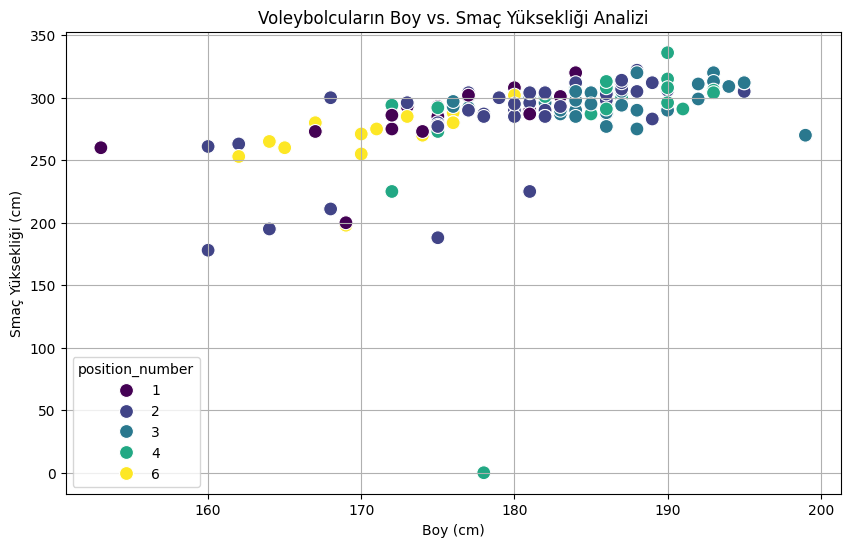

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Duplicate kayıtları temizle
df_clean = df.drop_duplicates(subset=['name'])

# 2. Temiz veriyle "En Patlayıcı 5 Oyuncu"
print("--- Temizlenmiş En Patlayıcı 5 Oyuncu ---")
top_jumpers_clean = df_clean[['name', 'position_number', 'height', 'spike', 'jump_power']].sort_values(by='jump_power', ascending=False).head()
print(top_jumpers_clean)

#Mevkilere Göre Boy ve Smaç Yüksekliği İlişkisi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='height', y='spike', hue='position_number', palette='viridis', s=100)
plt.title('Voleybolcuların Boy vs. Smaç Yüksekliği Analizi')
plt.xlabel('Boy (cm)')
plt.ylabel('Smaç Yüksekliği (cm)')
plt.grid(True)
plt.show()

In [4]:
#"Hızlı Arama" Fonksiyonu
def oyuncu_bul(min_spike, max_height):
    # Belirli bir smaç yüksekliğinin üzerinde ama boyu şu seviyenin altında olan "verimli" oyuncular
    filtre = df_clean[(df_clean['spike'] >= min_spike) & (df_clean['height'] <= max_height)]
    return filtre[['name', 'country', 'height', 'spike', 'jump_power']].sort_values(by='spike', ascending=False)

# Örnek: "Bana boyu 185'ten kısa ama 310+ smaç vuran oyuncuları getir"
ozel_liste = oyuncu_bul(min_spike=310, max_height=185)
print("--- Antrenörün Özel Scouting Listesi ---")
print(ozel_liste)

--- Antrenörün Özel Scouting Listesi ---
                         name  country  height  spike  jump_power
80   Anaila Martinez Chaviano       31     184    320         136
116              Angela Leyva       30     184    312         128


In [5]:
from dash import Dash, html, dcc, Input, Output, State, dash_table
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import base64
import io
from datetime import date

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Table, TableStyle,
                                Paragraph, Spacer, HRFlowable)

# ── Data preparation ───────────────────────────────────────────────────────
df = pd.read_csv('clean_data.csv')
df_clean = df.drop_duplicates(subset=['name']).copy()
df_clean['jump_power']        = df_clean['spike'] - df_clean['height']
df_clean['spike_percentile']  = df_clean['spike'].rank(pct=True) * 100
df_clean['block_percentile']  = df_clean['block'].rank(pct=True) * 100
df_clean['scout_score']       = (df_clean['spike_percentile'] + df_clean['block_percentile']) / 2

POSITION_NAMES = {
    1: 'Setter',
    2: 'Opposite Hitter',
    3: 'Middle Blocker',
    4: 'Outside Hitter',
    6: 'Libero',
}
df_clean['position_name'] = df_clean['position_number'].map(POSITION_NAMES)

METRICS = ['height', 'spike', 'block', 'jump_power']
METRIC_LABELS = {
    'height':     'Height (cm)',
    'spike':      'Spike Reach (cm)',
    'block':      'Block Reach (cm)',
    'jump_power': 'Jump Power (cm)',
}
METRIC_SHORT = {
    'height': 'Height', 'spike': 'Spike', 'block': 'Block', 'jump_power': 'Jump Pwr'
}

RADAR_METRICS = ['height', 'spike', 'block', 'jump_power', 'spike_percentile', 'block_percentile']
RADAR_LABELS = {
    'height':           'Height',
    'spike':            'Spike Reach',
    'block':            'Block Reach',
    'jump_power':       'Jump Power',
    'spike_percentile': 'Spike %ile',
    'block_percentile': 'Block %ile',
}
RADAR_RAW_LABELS = {
    'height':           'Height (cm)',
    'spike':            'Spike Reach (cm)',
    'block':            'Block Reach (cm)',
    'jump_power':       'Jump Power (cm)',
    'spike_percentile': 'Spike Percentile (%)',
    'block_percentile': 'Block Percentile (%)',
}

_metric_min = {m: df_clean[m].min() for m in RADAR_METRICS}
_metric_max = {m: df_clean[m].max() for m in RADAR_METRICS}

def normalize(value, metric):
    mn, mx = _metric_min[metric], _metric_max[metric]
    if mx == mn:
        return 50.0
    return round((value - mn) / (mx - mn) * 100, 1)

_sorted = df_clean.sort_values(['position_number', 'name'])
player_options = [
    {
        'label': f"{row['name']} — {POSITION_NAMES.get(row['position_number'], '?')}",
        'value': row['name'],
    }
    for _, row in _sorted.iterrows()
]
default_p1 = player_options[0]['value']
default_p2 = player_options[1]['value']

# ── Benchmark data ─────────────────────────────────────────────────────────
benchmark_rows = []
for pos_num, pos_name in POSITION_NAMES.items():
    pos_df = df_clean[df_clean['position_number'] == pos_num]
    if pos_df.empty:
        continue
    row = {'Position': pos_name, '_order': pos_num}
    for m in METRICS:
        row[f'{m}_avg']   = round(pos_df[m].mean(), 1)
        row[f'{m}_top25'] = round(pos_df[m].quantile(0.75), 1)
        row[f'{m}_elite'] = round(pos_df[m].quantile(0.90), 1)
    benchmark_rows.append(row)

benchmark_df = (pd.DataFrame(benchmark_rows)
                  .sort_values('_order')
                  .drop(columns='_order')
                  .reset_index(drop=True))

benchmark_avgs = {
    pos_num: {m: df_clean[df_clean['position_number'] == pos_num][m].mean() for m in METRICS}
    for pos_num in POSITION_NAMES
    if not df_clean[df_clean['position_number'] == pos_num].empty
}

TABLE_COLS = [{'name': 'Position', 'id': 'Position'}]
for m in METRICS:
    lbl = METRIC_SHORT[m]
    TABLE_COLS += [
        {'name': f'{lbl} Avg',       'id': f'{m}_avg'},
        {'name': f'{lbl} Top 25%',   'id': f'{m}_top25'},
        {'name': f'{lbl} Elite 10%', 'id': f'{m}_elite'},
    ]

SAMPLE_CSV = (
    "name,position_number,height,spike,block\n"
    "Anna Müller,1,176,284,273\n"
    "Sophie Chen,2,181,288,276\n"
    "Maria Santos,3,187,295,284\n"
    "Elena Popova,4,183,281,270\n"
    "Kim Lee,6,170,268,261\n"
)

# ── PDF generation ─────────────────────────────────────────────────────────
PDF_METRICS = [
    ('Height',           'height',           'cm'),
    ('Spike Reach',      'spike',            'cm'),
    ('Block Reach',      'block',            'cm'),
    ('Jump Power',       'jump_power',       'cm'),
    ('Spike Percentile', 'spike_percentile', '%'),
    ('Block Percentile', 'block_percentile', '%'),
]

_PDF_NAVY    = colors.HexColor('#2c3e50')
_PDF_CRIMSON = colors.HexColor('#7b241c')
_PDF_GREEN   = colors.HexColor('#1e8449')
_PDF_LGRAY   = colors.HexColor('#f5f5f5')
_PDF_MGRAY   = colors.HexColor('#bdc3c7')
_PDF_DGRAY   = colors.HexColor('#555555')

def _pct_rank(value, col):
    """Fraction of df_clean rows with col <= value, expressed as 0-100."""
    return round((df_clean[col] <= value).mean() * 100, 1)

def _player_metric_table(row):
    data = [['Metric', 'Value', 'Percentile Rank']]
    for label, col, unit in PDF_METRICS:
        val = float(row[col])
        pct = _pct_rank(val, col)
        data.append([label, f"{val:.1f} {unit}", f"{pct}%"])
    t = Table(data, colWidths=[7*cm, 5*cm, 6*cm])
    t.setStyle(TableStyle([
        ('BACKGROUND',     (0, 0), (-1,  0), _PDF_NAVY),
        ('TEXTCOLOR',      (0, 0), (-1,  0), colors.white),
        ('FONTNAME',       (0, 0), (-1,  0), 'Helvetica-Bold'),
        ('FONTSIZE',       (0, 0), (-1,  0), 10),
        ('ALIGN',          (0, 0), (-1, -1), 'CENTER'),
        ('ALIGN',          (0, 1), ( 0, -1), 'LEFT'),
        ('FONTSIZE',       (0, 1), (-1, -1), 9),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, _PDF_LGRAY]),
        ('GRID',           (0, 0), (-1, -1), 0.4, _PDF_MGRAY),
        ('TOPPADDING',     (0, 0), (-1, -1), 5),
        ('BOTTOMPADDING',  (0, 0), (-1, -1), 5),
        ('LEFTPADDING',    (0, 0), (-1, -1), 7),
    ]))
    return t

def _h2h_comparison_table(row1, row2, p1_name, p2_name):
    p1s = p1_name.split()[0]
    p2s = p2_name.split()[0]
    data = [['Metric', p1s, p2s, 'Edge']]
    win_style = []

    for i, (label, col, unit) in enumerate(PDF_METRICS, start=1):
        v1, v2 = float(row1[col]), float(row2[col])
        s1 = f"{v1:.1f} {unit}"
        s2 = f"{v2:.1f} {unit}"
        if v1 > v2:
            edge = f'{p1s} ▲'
            win_style += [
                ('BACKGROUND', (1, i), (1, i), _PDF_GREEN),
                ('TEXTCOLOR',  (1, i), (1, i), colors.white),
                ('FONTNAME',   (1, i), (1, i), 'Helvetica-Bold'),
            ]
        elif v2 > v1:
            edge = f'{p2s} ▲'
            win_style += [
                ('BACKGROUND', (2, i), (2, i), _PDF_GREEN),
                ('TEXTCOLOR',  (2, i), (2, i), colors.white),
                ('FONTNAME',   (2, i), (2, i), 'Helvetica-Bold'),
            ]
        else:
            edge = 'Tie'
        data.append([label, s1, s2, edge])

    t = Table(data, colWidths=[5.5*cm, 4*cm, 4*cm, 4.5*cm])
    base_style = [
        ('BACKGROUND',     (0,  0), (-1,  0), _PDF_NAVY),
        ('TEXTCOLOR',      (0,  0), (-1,  0), colors.white),
        ('FONTNAME',       (0,  0), (-1,  0), 'Helvetica-Bold'),
        ('FONTSIZE',       (0,  0), (-1,  0), 10),
        ('ALIGN',          (0,  0), (-1, -1), 'CENTER'),
        ('ALIGN',          (0,  1), ( 0, -1), 'LEFT'),
        ('FONTSIZE',       (0,  1), (-1, -1), 9),
        ('ROWBACKGROUNDS', (0,  1), (-1, -1), [colors.white, _PDF_LGRAY]),
        ('GRID',           (0,  0), (-1, -1), 0.4, _PDF_MGRAY),
        ('TOPPADDING',     (0,  0), (-1, -1), 5),
        ('BOTTOMPADDING',  (0,  0), (-1, -1), 5),
        ('LEFTPADDING',    (0,  0), (-1, -1), 7),
    ]
    t.setStyle(TableStyle(base_style + win_style))
    return t

def _build_recommendation(row1, row2, p1_name, p2_name):
    p1_pos = POSITION_NAMES.get(int(row1['position_number']), 'Unknown')
    p2_pos = POSITION_NAMES.get(int(row2['position_number']), 'Unknown')

    p1_leads, p2_leads = [], []
    for label, col, _ in PDF_METRICS:
        v1, v2 = float(row1[col]), float(row2[col])
        if v1 > v2:
            p1_leads.append(label)
        elif v2 > v1:
            p2_leads.append(label)

    p1_wins, p2_wins = len(p1_leads), len(p2_leads)
    total = len(PDF_METRICS)

    if p1_wins > p2_wins:
        stronger, weaker   = p1_name, p2_name
        stronger_pos       = p1_pos
        s_wins             = p1_wins
        s_metrics, w_metrics = p1_leads, p2_leads
    elif p2_wins > p1_wins:
        stronger, weaker   = p2_name, p1_name
        stronger_pos       = p2_pos
        s_wins             = p2_wins
        s_metrics, w_metrics = p2_leads, p1_leads
    else:
        # Spike tiebreaker
        if float(row1['spike']) >= float(row2['spike']):
            stronger, weaker   = p1_name, p2_name
            stronger_pos       = p1_pos
            s_metrics, w_metrics = p1_leads, p2_leads
        else:
            stronger, weaker   = p2_name, p1_name
            stronger_pos       = p2_pos
            s_metrics, w_metrics = p2_leads, p1_leads
        s_wins = p1_wins

    if p1_wins == p2_wins:
        intro = (
            f"The comparison between {p1_name} ({p1_pos}) and {p2_name} ({p2_pos}) "
            f"is evenly matched — each player leads in {p1_wins} of {total} categories, "
            f"with {stronger} earning a narrow edge on spike reach as the tiebreaker."
        )
    else:
        intro = (
            f"{stronger} ({stronger_pos}) holds a clear overall advantage, "
            f"leading in {s_wins} of {total} measured categories."
        )

    detail = ''
    if s_metrics:
        detail += f" {stronger} excels in: {', '.join(s_metrics)}."
    if w_metrics:
        detail += f" {weaker} counters with an edge in: {', '.join(w_metrics)}."

    # Jump power note (meaningful if gap ≥ 8 cm)
    jp1, jp2 = float(row1['jump_power']), float(row2['jump_power'])
    jp_note = ''
    if abs(jp1 - jp2) >= 8:
        jp_winner = p1_name if jp1 > jp2 else p2_name
        jp_note = (
            f" A jump-power differential of {abs(jp1 - jp2):.0f} cm in favour of "
            f"{jp_winner} signals superior explosive ability at the net."
        )

    # Spike percentile note (meaningful if gap ≥ 10 pp)
    sp1, sp2 = float(row1['spike_percentile']), float(row2['spike_percentile'])
    sp_note = ''
    if abs(sp1 - sp2) >= 10:
        sp_winner = p1_name if sp1 > sp2 else p2_name
        top_pct   = round(100 - max(sp1, sp2), 0)
        sp_note   = (
            f" {sp_winner}'s spike reach places them in the top {top_pct:.0f}% "
            f"of all scouted athletes — an elite attacking asset."
        )

    closing = (
        " Recommendation: weigh positional need and tactical system fit "
        "alongside these metrics before finalising any recruitment decision."
    )

    return intro + detail + jp_note + sp_note + closing

def generate_scouting_pdf(player1_name, player2_name):
    row1  = df_clean[df_clean['name'] == player1_name].iloc[0]
    row2  = df_clean[df_clean['name'] == player2_name].iloc[0]
    p1_pos = POSITION_NAMES.get(int(row1['position_number']), 'Unknown')
    p2_pos = POSITION_NAMES.get(int(row2['position_number']), 'Unknown')

    buf = io.BytesIO()
    doc = SimpleDocTemplate(
        buf, pagesize=A4,
        leftMargin=1.5*cm, rightMargin=1.5*cm,
        topMargin=1.5*cm,  bottomMargin=1.5*cm,
    )

    styles  = getSampleStyleSheet()
    sub_style = ParagraphStyle(
        'Sub', parent=styles['Normal'],
        fontSize=9, textColor=colors.grey, spaceAfter=2,
    )
    sec_style = ParagraphStyle(
        'Sec', parent=styles['Normal'],
        fontSize=13, textColor=_PDF_NAVY, fontName='Helvetica-Bold',
        spaceBefore=12, spaceAfter=5,
    )
    body_style = ParagraphStyle(
        'Body', parent=styles['Normal'],
        fontSize=9.5, leading=14, textColor=_PDF_DGRAY,
    )
    pos_style = ParagraphStyle(
        'Pos', parent=styles['Normal'],
        fontSize=10, textColor=_PDF_DGRAY, spaceAfter=4,
    )

    story = []

    # ── Header ───────────────────────────────────────────────────────────
    hdr = Table(
        [['Volleyball Scouting Report', 'CONFIDENTIAL']],
        colWidths=[12*cm, 6*cm],
    )
    hdr.setStyle(TableStyle([
        ('BACKGROUND',    (0, 0), (0, 0), _PDF_NAVY),
        ('BACKGROUND',    (1, 0), (1, 0), _PDF_CRIMSON),
        ('TEXTCOLOR',     (0, 0), (-1, 0), colors.white),
        ('FONTNAME',      (0, 0), (0, 0), 'Helvetica-Bold'),
        ('FONTSIZE',      (0, 0), (0, 0), 18),
        ('FONTNAME',      (1, 0), (1, 0), 'Helvetica-Bold'),
        ('FONTSIZE',      (1, 0), (1, 0), 11),
        ('ALIGN',         (0, 0), (0, 0), 'LEFT'),
        ('ALIGN',         (1, 0), (1, 0), 'RIGHT'),
        ('VALIGN',        (0, 0), (-1, 0), 'MIDDLE'),
        ('TOPPADDING',    (0, 0), (-1, 0), 14),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 14),
        ('LEFTPADDING',   (0, 0), (0, 0), 12),
        ('RIGHTPADDING',  (1, 0), (1, 0), 12),
    ]))
    story.append(hdr)
    story.append(Spacer(1, 0.15*cm))
    story.append(Paragraph(
        f"Generated: {date.today().strftime('%d %B %Y')}  ·  Internal Use Only",
        sub_style,
    ))
    story.append(HRFlowable(width='100%', thickness=1.5, color=_PDF_NAVY, spaceAfter=8))

    # ── Player 1 ─────────────────────────────────────────────────────────
    story.append(Paragraph(f"Player 1: {player1_name}", sec_style))
    story.append(Paragraph(f"Position: {p1_pos}", pos_style))
    story.append(_player_metric_table(row1))

    story.append(Spacer(1, 0.5*cm))

    # ── Player 2 ─────────────────────────────────────────────────────────
    story.append(Paragraph(f"Player 2: {player2_name}", sec_style))
    story.append(Paragraph(f"Position: {p2_pos}", pos_style))
    story.append(_player_metric_table(row2))

    story.append(Spacer(1, 0.5*cm))

    # ── Head-to-Head ─────────────────────────────────────────────────────
    story.append(Paragraph("Head-to-Head Comparison", sec_style))
    story.append(Paragraph(
        "Green cells indicate the higher value for each metric.",
        ParagraphStyle('note', parent=styles['Normal'],
                       fontSize=8, textColor=colors.grey, spaceAfter=4),
    ))
    story.append(_h2h_comparison_table(row1, row2, player1_name, player2_name))

    story.append(Spacer(1, 0.5*cm))

    # ── Scout Recommendation ─────────────────────────────────────────────
    story.append(Paragraph("Scout Recommendation", sec_style))
    story.append(HRFlowable(width='100%', thickness=0.5, color=_PDF_MGRAY, spaceAfter=6))
    rec_text = _build_recommendation(row1, row2, player1_name, player2_name)
    story.append(Paragraph(rec_text, body_style))

    doc.build(story)
    buf.seek(0)
    return buf.read()


# ── Shared Dash styles ────────────────────────────────────────────────────
HEADER    = {'textAlign': 'center', 'color': '#2c3e50', 'fontFamily': 'Arial'}
PANEL     = {'padding': '20px', 'backgroundColor': '#f9f9f9', 'borderRadius': '10px', 'marginTop': '10px'}
LABEL     = {'fontWeight': 'bold', 'fontFamily': 'Arial'}
SECTION_H = {
    'color': '#2c3e50', 'fontFamily': 'Arial',
    'marginTop': '28px', 'paddingBottom': '6px',
    'borderBottom': '2px solid #2c3e50',
}
TABLE_HEADER_STYLE = {
    'backgroundColor': '#2c3e50', 'color': 'white',
    'fontWeight': 'bold', 'textAlign': 'center',
    'fontFamily': 'Arial', 'fontSize': '12px',
}
TABLE_CELL_STYLE = {
    'textAlign': 'center', 'fontFamily': 'Arial',
    'fontSize': '13px', 'padding': '8px',
}
ODD_ROW = [{'if': {'row_index': 'odd'}, 'backgroundColor': '#f5f5f5'}]
BTN_STYLE = {
    'padding': '10px 22px', 'backgroundColor': '#2c3e50', 'color': 'white',
    'border': 'none', 'borderRadius': '5px', 'cursor': 'pointer',
    'fontFamily': 'Arial', 'fontSize': '14px', 'fontWeight': 'bold',
}


# ── Team Analysis helpers ──────────────────────────────────────────────────
def parse_csv(contents, filename):
    _, content_string = contents.split(',')
    try:
        decoded = base64.b64decode(content_string)
        team_df = pd.read_csv(io.StringIO(decoded.decode('utf-8')))
    except Exception as exc:
        return None, f"Could not parse file: {exc}"
    required = {'name', 'position_number', 'height', 'spike', 'block'}
    missing  = required - set(team_df.columns)
    if missing:
        return None, f"Missing columns: {', '.join(sorted(missing))}"
    team_df = team_df[list(required)].copy()
    team_df['position_number'] = pd.to_numeric(team_df['position_number'], errors='coerce')
    for col in ['height', 'spike', 'block']:
        team_df[col] = pd.to_numeric(team_df[col], errors='coerce')
    team_df = team_df.dropna().reset_index(drop=True)
    if team_df.empty:
        return None, "No valid rows found after parsing."
    team_df['jump_power']    = team_df['spike'] - team_df['height']
    team_df['position_name'] = team_df['position_number'].map(POSITION_NAMES).fillna('Unknown')
    return team_df, None

def build_squad_chart(team_df):
    counts  = team_df.groupby('position_number').size().reset_index(name='count')
    all_pos = pd.DataFrame({
        'position_number': list(POSITION_NAMES.keys()),
        'position_name':   list(POSITION_NAMES.values()),
    })
    counts  = all_pos.merge(counts, on='position_number', how='left').fillna(0)
    counts['count'] = counts['count'].astype(int)
    colors_ = ['#e74c3c' if n == 0 else '#5b8db8' for n in counts['count']]
    fig = go.Figure(go.Bar(
        x=counts['position_name'], y=counts['count'],
        marker_color=colors_, text=counts['count'], textposition='outside',
    ))
    fig.update_layout(
        title='Players per Position  (red = missing)',
        xaxis_title='Position', yaxis_title='Number of Players',
        yaxis=dict(dtick=1, gridcolor='#eeeeee', rangemode='tozero'),
        plot_bgcolor='white', font=dict(family='Arial'), showlegend=False,
    )
    return fig

def build_weakness_section(team_df):
    compare_metrics = ['height', 'spike', 'block', 'jump_power']
    rows, below_cells = [], []
    for i, (_, player) in enumerate(team_df.iterrows()):
        pos_num = int(player['position_number'])
        avgs    = benchmark_avgs.get(pos_num, {})
        row     = {'name': player['name'], 'position': POSITION_NAMES.get(pos_num, 'Unknown')}
        for m in compare_metrics:
            val = round(float(player[m]), 1)
            row[m] = val
            if avgs and val < avgs.get(m, val + 1):
                below_cells.append((i, m))
        rows.append(row)

    weakness_table = dash_table.DataTable(
        columns=[
            {'name': 'Name',        'id': 'name'},
            {'name': 'Position',    'id': 'position'},
            {'name': 'Height (cm)', 'id': 'height'},
            {'name': 'Spike (cm)',  'id': 'spike'},
            {'name': 'Block (cm)',  'id': 'block'},
            {'name': 'Jump Power',  'id': 'jump_power'},
        ],
        data=rows,
        style_table={'overflowX': 'auto'},
        style_header=TABLE_HEADER_STYLE,
        style_cell=TABLE_CELL_STYLE,
        style_data_conditional=ODD_ROW + [
            {'if': {'row_index': r, 'column_id': col},
             'backgroundColor': '#fde8e8', 'color': '#c0392b', 'fontWeight': 'bold'}
            for r, col in below_cells
        ],
    )

    score_rows = []
    for pos_num, pos_name in POSITION_NAMES.items():
        pos_players = team_df[team_df['position_number'] == pos_num]
        avgs        = benchmark_avgs.get(pos_num, {})
        if pos_players.empty or not avgs:
            score_rows.append({'position': pos_name, 'players': 0,
                               'score': None, 'status': 'Missing', 'color': '#e74c3c'})
            continue
        scores = [(pos_players[m].mean() / avgs[m]) * 100 for m in ['height', 'spike', 'block']]
        score  = round(sum(scores) / len(scores), 1)
        if score >= 97:   status, color = 'Strong',  '#27ae60'
        elif score >= 90: status, color = 'Average', '#f39c12'
        else:             status, color = 'Weak',    '#e74c3c'
        score_rows.append({'position': pos_name, 'players': len(pos_players),
                           'score': score, 'status': status, 'color': color})

    score_cards = html.Div([
        html.H4("Team Score by Position",
                style={'fontFamily': 'Arial', 'color': '#2c3e50', 'marginTop': '16px'}),
        html.P("Score = team average as % of benchmark average. Green ≥ 97 · Yellow ≥ 90 · Red < 90",
               style={'color': '#666', 'fontFamily': 'Arial', 'fontSize': '12px'}),
        html.Div([
            html.Div([
                html.Div(r['position'],
                         style={'fontFamily': 'Arial', 'fontWeight': 'bold', 'fontSize': '12px'}),
                html.Div(f"{r['score']}%" if r['score'] is not None else '—',
                         style={'fontSize': '22px', 'fontWeight': 'bold',
                                'color': r['color'], 'fontFamily': 'Arial'}),
                html.Div(r['status'],
                         style={'color': r['color'], 'fontFamily': 'Arial', 'fontSize': '12px'}),
                html.Div(f"{r['players']} player(s)",
                         style={'color': '#999', 'fontFamily': 'Arial', 'fontSize': '11px'}),
            ], style={
                'display': 'inline-block', 'textAlign': 'center',
                'padding': '12px 18px', 'margin': '6px',
                'border': f"2px solid {r['color']}",
                'borderRadius': '8px', 'minWidth': '115px', 'backgroundColor': 'white',
            })
            for r in score_rows
        ]),
    ])
    return score_cards, weakness_table, score_rows

def build_transfer_section(score_rows):
    targets = [r for r in score_rows if r['status'] in ('Weak', 'Missing')]
    if not targets:
        return html.P("No weak or missing positions — great squad!",
                      style={'color': '#27ae60', 'fontFamily': 'Arial', 'fontWeight': 'bold'})
    sections = []
    for r in targets:
        pos_num    = next(k for k, v in POSITION_NAMES.items() if v == r['position'])
        candidates = (df_clean[df_clean['position_number'] == pos_num]
                      .sort_values('scout_score', ascending=False).head(5))
        subtitle   = '(missing)' if r['status'] == 'Missing' else f"(score: {r['score']}%)"
        rec_rows   = [
            {
                'name':       row['name'],
                'country':    int(row['country']) if pd.notna(row['country']) else '?',
                'height':     int(row['height']),
                'spike':      int(row['spike']),
                'block':      int(row['block']),
                'jump_power': int(row['jump_power']),
                'spike_%ile': round(row['spike_percentile'], 1),
            }
            for _, row in candidates.iterrows()
        ]
        sections.append(html.Div([
            html.H5(f"{r['position']}  {subtitle}",
                    style={'color': r['color'], 'fontFamily': 'Arial', 'marginTop': '16px'}),
            dash_table.DataTable(
                columns=[
                    {'name': 'Name',        'id': 'name'},
                    {'name': 'Country',     'id': 'country'},
                    {'name': 'Height (cm)', 'id': 'height'},
                    {'name': 'Spike (cm)',  'id': 'spike'},
                    {'name': 'Block (cm)',  'id': 'block'},
                    {'name': 'Jump Power',  'id': 'jump_power'},
                    {'name': 'Spike %ile',  'id': 'spike_%ile'},
                ],
                data=rec_rows,
                style_table={'overflowX': 'auto'},
                style_header=TABLE_HEADER_STYLE,
                style_cell=TABLE_CELL_STYLE,
                style_data_conditional=ODD_ROW,
            ),
        ]))
    return html.Div(sections)


# ── App ────────────────────────────────────────────────────────────────────
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Voleybol Scouting Karar Destek Paneli", style=HEADER),

    dcc.Tabs(value='tab-scout', children=[

        # ── Tab 1: player scout ──────────────────────────────────────────
        dcc.Tab(label='Player Scout', value='tab-scout', children=[
            html.Div([
                html.Div([
                    html.Label("Minimum Smaç Yüksekliği (cm):", style=LABEL),
                    dcc.Slider(id='spike-slider', min=250, max=350, step=5, value=300,
                               marks={i: str(i) for i in range(250, 351, 20)}),
                ], style={'width': '48%', 'display': 'inline-block'}),
                html.Div([
                    html.Label("Maksimum Boy (cm):", style=LABEL),
                    dcc.Slider(id='height-slider', min=160, max=210, step=1, value=185,
                               marks={i: str(i) for i in range(160, 211, 10)}),
                ], style={'width': '48%', 'display': 'inline-block', 'float': 'right'}),
            ], style=PANEL),
            dcc.Graph(id='scout-graph'),
        ]),

        # ── Tab 2: position benchmarks ───────────────────────────────────
        dcc.Tab(label='Position Benchmarks', value='tab-benchmarks', children=[
            html.Div([
                html.H3("Position Benchmark Standards",
                        style={'color': '#2c3e50', 'fontFamily': 'Arial'}),
                html.P("Deduplicated player records only. "
                       "Top 25% = 75th percentile · Elite 10% = 90th percentile.",
                       style={'color': '#666', 'fontFamily': 'Arial', 'fontSize': '13px'}),
                dash_table.DataTable(
                    columns=TABLE_COLS, data=benchmark_df.to_dict('records'),
                    style_table={'overflowX': 'auto'},
                    style_header=TABLE_HEADER_STYLE,
                    style_cell={**TABLE_CELL_STYLE, 'minWidth': '70px'},
                    style_data_conditional=(
                        ODD_ROW +
                        [{'if': {'column_id': f'{m}_elite'},
                          'backgroundColor': '#fff3cd', 'fontWeight': 'bold'}
                         for m in METRICS]
                    ),
                ),
                html.Br(),
                html.Div([
                    html.Label("Select metric to visualise:", style=LABEL),
                    dcc.Dropdown(
                        id='benchmark-metric',
                        options=[{'label': METRIC_LABELS[m], 'value': m} for m in METRICS],
                        value='spike', clearable=False, style={'width': '300px'},
                    ),
                ], style={'marginBottom': '10px'}),
                dcc.Graph(id='benchmark-bar'),
            ], style=PANEL),
        ]),

        # ── Tab 3: player comparison ─────────────────────────────────────
        dcc.Tab(label='Player Comparison', value='tab-compare', children=[
            html.Div([
                html.H3("Head-to-Head Player Comparison",
                        style={'color': '#2c3e50', 'fontFamily': 'Arial'}),
                html.P("All six metrics are normalized to a 0–100 scale for visual comparison. "
                       "Spike Percentile and Block Percentile show rank within the full dataset.",
                       style={'color': '#666', 'fontFamily': 'Arial', 'fontSize': '13px'}),

                # Player selectors
                html.Div([
                    html.Div([
                        html.Label("Player 1", style={**LABEL, 'color': '#2980b9'}),
                        dcc.Dropdown(id='player1-dropdown', options=player_options,
                                     value=default_p1, clearable=False),
                    ], style={'width': '45%', 'display': 'inline-block'}),
                    html.Div([
                        html.Label("Player 2", style={**LABEL, 'color': '#e74c3c'}),
                        dcc.Dropdown(id='player2-dropdown', options=player_options,
                                     value=default_p2, clearable=False),
                    ], style={'width': '45%', 'display': 'inline-block', 'float': 'right'}),
                ], style={'marginBottom': '16px'}),

                # PDF button
                html.Div([
                    html.Button('Generate PDF Report', id='btn-pdf', style=BTN_STYLE),
                    dcc.Download(id='download-pdf'),
                    html.Span(
                        ' Downloads a confidential scouting report for the two selected players.',
                        style={'color': '#888', 'fontFamily': 'Arial',
                               'fontSize': '12px', 'marginLeft': '12px'},
                    ),
                ], style={'marginBottom': '20px'}),

                dcc.Graph(id='comparison-radar'),
                html.Br(),
                dash_table.DataTable(
                    id='comparison-table',
                    style_table={'overflowX': 'auto', 'maxWidth': '560px'},
                    style_header=TABLE_HEADER_STYLE,
                    style_cell=TABLE_CELL_STYLE,
                    style_data_conditional=ODD_ROW,
                ),
            ], style=PANEL),
        ]),

        # ── Tab 4: team analysis ─────────────────────────────────────────
        dcc.Tab(label='Team Analysis', value='tab-team', children=[
            html.Div([
                html.H3("Team Analysis", style={'color': '#2c3e50', 'fontFamily': 'Arial'}),
                html.P("Upload a CSV with your team's roster to analyse squad composition, "
                       "detect individual weaknesses, and get transfer recommendations.",
                       style={'color': '#666', 'fontFamily': 'Arial', 'fontSize': '13px'}),
                dcc.Upload(
                    id='team-upload',
                    children=html.Div([
                        'Drag and Drop or ',
                        html.A('Select a CSV File',
                               style={'color': '#2980b9', 'cursor': 'pointer'}),
                    ]),
                    style={
                        'width': '100%', 'height': '60px', 'lineHeight': '60px',
                        'borderWidth': '2px', 'borderStyle': 'dashed',
                        'borderRadius': '8px', 'borderColor': '#aaa',
                        'textAlign': 'center', 'fontFamily': 'Arial',
                        'cursor': 'pointer', 'backgroundColor': 'white',
                        'boxSizing': 'border-box',
                    },
                    multiple=False, accept='.csv',
                ),
                html.Div([
                    html.Button('Download Sample CSV', id='btn-sample', style={
                        **BTN_STYLE,
                        'marginTop': '10px', 'fontSize': '13px',
                        'fontWeight': 'normal', 'padding': '8px 16px',
                    }),
                    dcc.Download(id='download-sample'),
                    html.P("Required columns: name · position_number · height · spike · block",
                           style={'color': '#888', 'fontFamily': 'Arial',
                                  'fontSize': '11px', 'marginTop': '5px'}),
                ], style={'marginBottom': '20px'}),
                html.Div(
                    id='team-analysis-output',
                    children=html.P("Upload a CSV file above to see the analysis.",
                                    style={'color': '#aaa', 'fontFamily': 'Arial',
                                           'fontStyle': 'italic'}),
                ),
            ], style=PANEL),
        ]),
    ]),
], style={'padding': '20px'})


# ── Callbacks ──────────────────────────────────────────────────────────────

@app.callback(
    Output('scout-graph', 'figure'),
    [Input('spike-slider', 'value'), Input('height-slider', 'value')],
)
def update_scout(min_spike, max_height):
    filtered = df_clean[
        (df_clean['spike'] >= min_spike) & (df_clean['height'] <= max_height)
    ]
    fig = px.scatter(
        filtered, x='height', y='spike',
        hover_name='name', color='jump_power', size='jump_power',
        color_continuous_scale='Viridis',
        labels={'height': 'Boy (cm)', 'spike': 'Smaç Yüksekliği (cm)', 'jump_power': 'Zıplama Gücü'},
        title=f"Kriterlere Uygun {len(filtered)} Oyuncu Bulundu",
    )
    fig.update_layout(transition_duration=500)
    return fig


@app.callback(
    Output('benchmark-bar', 'figure'),
    Input('benchmark-metric', 'value'),
)
def update_benchmark_bar(metric):
    label     = METRIC_LABELS[metric]
    positions = benchmark_df['Position'].tolist()
    fig = go.Figure([
        go.Bar(name='Average',   x=positions, y=benchmark_df[f'{metric}_avg'],
               marker_color='#5b8db8', text=benchmark_df[f'{metric}_avg'],   textposition='outside'),
        go.Bar(name='Top 25%',   x=positions, y=benchmark_df[f'{metric}_top25'],
               marker_color='#f39c12', text=benchmark_df[f'{metric}_top25'], textposition='outside'),
        go.Bar(name='Elite 10%', x=positions, y=benchmark_df[f'{metric}_elite'],
               marker_color='#e74c3c', text=benchmark_df[f'{metric}_elite'], textposition='outside'),
    ])
    fig.update_layout(
        barmode='group', title=f'{label} — Benchmarks by Position',
        xaxis_title='Position', yaxis_title=label, legend_title='Benchmark Level',
        font={'family': 'Arial'}, plot_bgcolor='white',
        yaxis=dict(gridcolor='#eeeeee'),
        uniformtext_minsize=8, uniformtext_mode='hide',
    )
    return fig


@app.callback(
    Output('comparison-radar', 'figure'),
    Output('comparison-table', 'columns'),
    Output('comparison-table', 'data'),
    Input('player1-dropdown', 'value'),
    Input('player2-dropdown', 'value'),
)
def update_comparison(player1, player2):
    row1 = df_clean[df_clean['name'] == player1].iloc[0]
    row2 = df_clean[df_clean['name'] == player2].iloc[0]

    categories  = [RADAR_LABELS[m] for m in RADAR_METRICS]
    cats_closed = categories + [categories[0]]
    p1_norm = [normalize(row1[m], m) for m in RADAR_METRICS]
    p2_norm = [normalize(row2[m], m) for m in RADAR_METRICS]

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
        r=p1_norm + [p1_norm[0]], theta=cats_closed, fill='toself', name=player1,
        line=dict(color='#2980b9', width=2), fillcolor='rgba(41,128,185,0.2)',
    ))
    fig.add_trace(go.Scatterpolar(
        r=p2_norm + [p2_norm[0]], theta=cats_closed, fill='toself', name=player2,
        line=dict(color='#e74c3c', width=2), fillcolor='rgba(231,76,60,0.2)',
    ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 100], tickfont=dict(size=9))),
        showlegend=True, legend=dict(font=dict(family='Arial')),
        title=dict(text=f"{player1}  vs  {player2}",
                   font=dict(family='Arial', color='#2c3e50')),
        font=dict(family='Arial'),
    )

    pos1 = POSITION_NAMES.get(row1['position_number'], '?')
    pos2 = POSITION_NAMES.get(row2['position_number'], '?')
    table_data = (
        [{'metric': 'Position', 'p1': pos1, 'p2': pos2}] +
        [{'metric': RADAR_RAW_LABELS[m],
          'p1': round(row1[m], 1), 'p2': round(row2[m], 1)}
         for m in RADAR_METRICS]
    )
    table_cols = [
        {'name': 'Metric', 'id': 'metric'},
        {'name': player1,  'id': 'p1'},
        {'name': player2,  'id': 'p2'},
    ]
    return fig, table_cols, table_data


@app.callback(
    Output('download-pdf', 'data'),
    Input('btn-pdf', 'n_clicks'),
    State('player1-dropdown', 'value'),
    State('player2-dropdown', 'value'),
    prevent_initial_call=True,
)
def export_pdf(_, player1, player2):
    pdf_bytes = generate_scouting_pdf(player1, player2)
    p1s = player1.replace(' ', '_')
    p2s = player2.replace(' ', '_')
    return dcc.send_bytes(pdf_bytes, f"scouting_{p1s}_vs_{p2s}.pdf")


@app.callback(
    Output('download-sample', 'data'),
    Input('btn-sample', 'n_clicks'),
    prevent_initial_call=True,
)
def download_sample(_):
    return dcc.send_string(SAMPLE_CSV, 'team_sample.csv')


@app.callback(
    Output('team-analysis-output', 'children'),
    Input('team-upload', 'contents'),
    State('team-upload', 'filename'),
    prevent_initial_call=True,
)
def update_team_analysis(contents, filename):
    team_df, error = parse_csv(contents, filename)
    if error:
        return html.P(f"Error: {error}",
                      style={'color': '#e74c3c', 'fontFamily': 'Arial', 'fontWeight': 'bold'})

    squad_chart                            = build_squad_chart(team_df)
    score_cards, weakness_table, score_rows = build_weakness_section(team_df)
    transfer_content                       = build_transfer_section(score_rows)

    return html.Div([
        html.P(f"Loaded \"{filename}\" — {len(team_df)} players",
               style={'color': '#27ae60', 'fontFamily': 'Arial', 'fontWeight': 'bold'}),
        html.H4("Section A — Squad Overview", style=SECTION_H),
        dcc.Graph(figure=squad_chart),
        html.H4("Section B — Weakness Detection", style=SECTION_H),
        html.P("Red cells are below the position benchmark average.",
               style={'color': '#666', 'fontFamily': 'Arial', 'fontSize': '12px'}),
        score_cards,
        html.Br(),
        weakness_table,
        html.H4("Section C — Transfer Recommendations", style=SECTION_H),
        html.P("Top 5 candidates from the database for each weak or missing position, "
               "ranked by combined spike + block percentile.",
               style={'color': '#666', 'fontFamily': 'Arial', 'fontSize': '12px'}),
        transfer_content,
    ])


if __name__ == '__main__':
    app.run(mode='inline', port=8060)


In [6]:
!pip install reportlab -q